In [33]:
### Basic
import numpy  as np
import scipy  as sc
import pandas as pd
import glob, os, re
import pickle, sys

### sklearn
from sklearn.metrics import roc_curve, auc, accuracy_score

### import flowImg
py_path = "/local_data/notebooks/clintko/GitRepo/Proj_Flow2Image"
sys.path.insert(0, py_path)
from flowImg import *

### plotting
import matplotlib.pyplot as plt
plt.style.use('seaborn-darkgrid')

### directory
DAT_DIR = "/data/clintko/flow_EQAPOL_normal"

In [34]:
%matplotlib inline

In [35]:
def generate_sample(mean, cov, num_events):
    """Generate sample data from guassian mixed model"""
    assert mean.shape[0] == cov.shape[0]
    assert mean.shape[0] == num_events.shape[0]
    
    num_clusters = mean.shape[0]
    dat = [np.random.multivariate_normal(mean[idx], cov[idx], num_events[idx]) 
           for idx in range(num_clusters)]
    dat = np.concatenate(dat)
    return dat

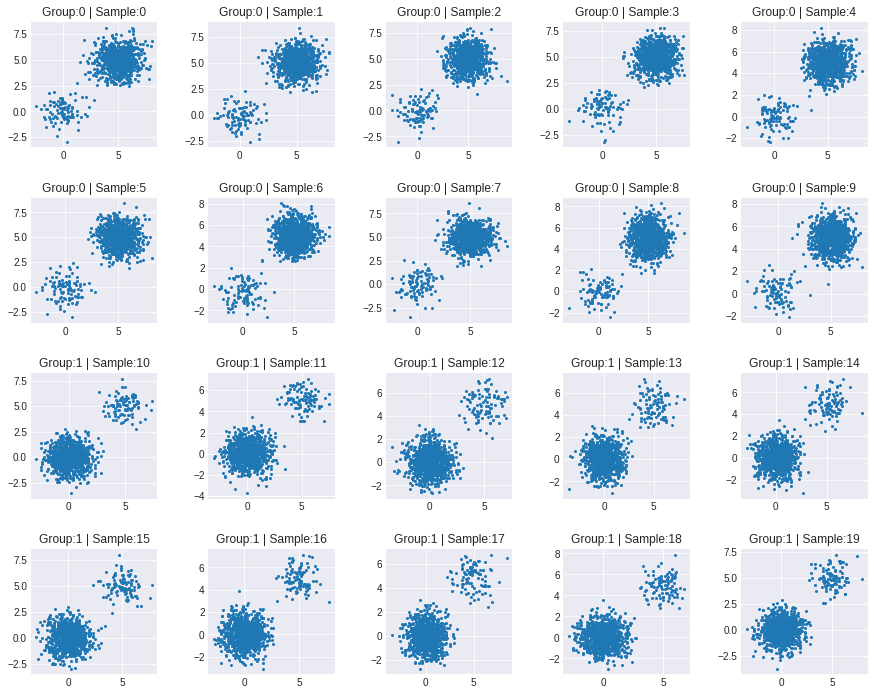

In [36]:
### Generate data
mu1 = np.array([[0, 0],[5, 5]])        ### Mean
sd1 = np.array([np.eye(2), np.eye(2)]) ### SD
nc1 = np.array([100, 900])             ### number of cells
ns1 = 10                               ### number of samples
y1  = np.array([generate_sample(mu1, sd1, nc1) for _ in range(ns1)])

mu2 = np.array([[0, 0],[5, 5]])        ### Mean
sd2 = np.array([np.eye(2), np.eye(2)]) ### SD
nc2 = np.array([900, 100])             ### number of cells
ns2 = 10                               ### number of samples
y2  = np.array([generate_sample(mu2, sd2, nc2) for _ in range(ns2)])

### combine the samples and set labels
matrix = np.concatenate([y1, y2])
label  = [0] * ns1 + [1] * ns2 

### visualization
fig, axes = plt.subplots(ncols=5, nrows=4, figsize = (3*5, 3*4))
plt.subplots_adjust(wspace = 0.4, hspace = 0.4)
axes = axes.ravel()

for idx, ax in enumerate(axes):
    ax.scatter(matrix[idx][:,0], matrix[idx][:, 1], s = 4)
    ax.set_title("Group:" + str(label[idx]) + " | Sample:" + str(idx))

In [37]:
### wrap up the data
print("STEP: wrap up the data")
print("+++++++++++++++++++++++++++++++++++")
%time dat_wrap = Data_Wrapper(matrix, label)
print(dat_wrap)

STEP: wrap up the data
+++++++++++++++++++++++++++++++++++
CPU times: user 2.12 ms, sys: 1.52 ms, total: 3.63 ms
Wall time: 951 µs
Label: Counter({0: 10, 1: 10})
    0: [0 1 2 3 4 5 6 7 8 9]
    1: [10 11 12 13 14 15 16 17 18 19]
------------------
Data Matrix: (20000, 2)
    #Samples:   20
    #Variables: 2
------------------
Coordinate: None
------------------
Image: None



In [38]:
### Standardize the data
print("STEP: Standardize the data")
print("+++++++++++++++++++++++++++++++++++")
scaler = Transform_StandardScaler(k = 0)
scaler = scaler.fit(dat_wrap)
%time dat_scaled = scaler.transform(dat_wrap)
print(dat_scaled)

STEP: Standardize the data
+++++++++++++++++++++++++++++++++++
Transform_StandardScaler(k=0)
Total Sample: 20
Standardized based on sample: 0

***** k_th Sample: 0 *****
Mean:
[4.47487694 4.49371359]
SD:
[1.81285663 1.76864728]

CPU times: user 1.95 ms, sys: 0 ns, total: 1.95 ms
Wall time: 1.52 ms
Label: Counter({0: 10, 1: 10})
    0: [0 1 2 3 4 5 6 7 8 9]
    1: [10 11 12 13 14 15 16 17 18 19]
------------------
Data Matrix: (20000, 2)
    #Samples:   20
    #Variables: 2
------------------
Coordinate: None
------------------
Image: None



In [39]:
### Subsetting
print("STEP: Subsetting")
print("+++++++++++++++++++++++++++++++++++")
sampler = Transform_Subsampling(n_subsample = 5, n_size = 100, random_state = 123)
%time dat_subs = sampler.fit_transform(dat_scaled)
print(dat_subs)

STEP: Subsetting
+++++++++++++++++++++++++++++++++++
CPU times: user 580 µs, sys: 4.47 ms, total: 5.05 ms
Wall time: 3.73 ms
Label: Counter({0: 50, 1: 50})
    0: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49]
    1: [50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73
 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96 97
 98 99]
------------------
Data Matrix: (10000, 2)
    #Samples:   100
    #Variables: 2
------------------
Coordinate: None
------------------
Image: None



In [40]:
### Dimensional Reduction: t-SNE
print("STEP: Dim.Reduct.")
print("+++++++++++++++++++++++++++++++++++")
tsne = Transform_TSNE(n_components = 2, n_jobs = 12, random_state = 123)
%time dat_tsne = tsne.transform(dat_subs, verbose=True)
print(dat_tsne)

STEP: Dim.Reduct.
+++++++++++++++++++++++++++++++++++
Sample: 0
Sample: 1
Sample: 2
Sample: 3
Sample: 4
Sample: 5
Sample: 6
Sample: 7
Sample: 8
Sample: 9
Sample: 10
Sample: 11
Sample: 12
Sample: 13
Sample: 14
Sample: 15
Sample: 16
Sample: 17
Sample: 18
Sample: 19
Sample: 20
Sample: 21
Sample: 22
Sample: 23
Sample: 24
Sample: 25
Sample: 26
Sample: 27
Sample: 28
Sample: 29
Sample: 30
Sample: 31
Sample: 32
Sample: 33
Sample: 34
Sample: 35
Sample: 36
Sample: 37
Sample: 38
Sample: 39
Sample: 40
Sample: 41
Sample: 42
Sample: 43
Sample: 44
Sample: 45
Sample: 46
Sample: 47
Sample: 48
Sample: 49
Sample: 50
Sample: 51
Sample: 52
Sample: 53
Sample: 54
Sample: 55
Sample: 56
Sample: 57
Sample: 58
Sample: 59
Sample: 60
Sample: 61
Sample: 62
Sample: 63
Sample: 64
Sample: 65
Sample: 66
Sample: 67
Sample: 68
Sample: 69
Sample: 70
Sample: 71
Sample: 72
Sample: 73
Sample: 74
Sample: 75
Sample: 76
Sample: 77
Sample: 78
Sample: 79
Sample: 80
Sample: 81
Sample: 82
Sample: 83
Sample: 84
Sample: 85
Sample: 86

In [41]:
### Kernel Density estimation
print("STEP: Kernel Density estimation")
print("+++++++++++++++++++++++++++++++++++")
density = Transform_Density(sig2 = 5)
%time dat_img = density.transform(dat_tsne, verbose=True)
print(dat_img)

STEP: Kernel Density estimation
+++++++++++++++++++++++++++++++++++
Sample: 0
Sample: 1
Sample: 2
Sample: 3
Sample: 4
Sample: 5
Sample: 6
Sample: 7
Sample: 8
Sample: 9
Sample: 10
Sample: 11
Sample: 12
Sample: 13
Sample: 14
Sample: 15
Sample: 16
Sample: 17
Sample: 18
Sample: 19
Sample: 20
Sample: 21
Sample: 22
Sample: 23
Sample: 24
Sample: 25
Sample: 26
Sample: 27
Sample: 28
Sample: 29
Sample: 30
Sample: 31
Sample: 32
Sample: 33
Sample: 34
Sample: 35
Sample: 36
Sample: 37
Sample: 38
Sample: 39
Sample: 40
Sample: 41
Sample: 42
Sample: 43
Sample: 44
Sample: 45
Sample: 46
Sample: 47
Sample: 48
Sample: 49
Sample: 50
Sample: 51
Sample: 52
Sample: 53
Sample: 54
Sample: 55
Sample: 56
Sample: 57
Sample: 58
Sample: 59
Sample: 60
Sample: 61
Sample: 62
Sample: 63
Sample: 64
Sample: 65
Sample: 66
Sample: 67
Sample: 68
Sample: 69
Sample: 70
Sample: 71
Sample: 72
Sample: 73
Sample: 74
Sample: 75
Sample: 76
Sample: 77
Sample: 78
Sample: 79
Sample: 80
Sample: 81
Sample: 82
Sample: 83
Sample: 84
Sample:

In [43]:
print(dat_img)

Label: Counter({0: 50, 1: 50})
    0: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49]
    1: [50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73
 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96 97
 98 99]
------------------
Data Matrix: (10000, 2)
    #Samples:   100
    #Variables: 2
------------------
Coordinate: (10000, 2)
------------------
Image: (100, 16384, 2)



In [59]:
dat_trn, dat_val = kfold(dat_img, 0, 10, 5)
print(dat_trn)
print(dat_val)

Label: Counter({0: 45, 1: 45})
    0: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44]
    1: [45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68
 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89]
------------------
Data Matrix: (9000, 2)
    #Samples:   90
    #Variables: 2
------------------
Coordinate: (9000, 2)
------------------
Image: (90, 16384, 2)

Label: Counter({0: 5, 1: 5})
    0: [0 1 2 3 4]
    1: [5 6 7 8 9]
------------------
Data Matrix: (1000, 2)
    #Samples:   10
    #Variables: 2
------------------
Coordinate: (1000, 2)
------------------
Image: (10, 16384, 2)



In [63]:
dat_trn, dat_val = kfold(dat_img, 0, 10, 5)
mat1 = dat_val.get_sample(k = 0)
mat2 = dat_img.get_sample(k = 0)
print(np.allclose(mat1, mat2))

dat_trn, dat_val = kfold(dat_img, 1, 10, 5)
mat1 = dat_val.get_sample(k = 0)
mat2 = dat_img.get_sample(k = 5)
print(np.allclose(mat1, mat2))

dat_trn, dat_val = kfold(dat_img, 2, 10, 5)
mat1 = dat_val.get_sample(k = 0)
mat2 = dat_img.get_sample(k = 10)
print(np.allclose(mat1, mat2))

True
True
True


In [57]:
def leave_one_out_split(dat, k, n_samples, n_subsamples):
    """divide the data into two parts"""
    ### the samples index after subsampling    
    idx_samples = np.array([[idx] * n_subsamples for idx in range(n_samples)])
    idx_samples = idx_samples.ravel()

    ### get the overall index for train and validation
    idx_trn = np.where(idx_samples != k)[0]
    idx_val = np.where(idx_samples == k)[0]
    
    ### for each label, get the index for train and validation
    idx_trn = np.concatenate([
        dat.which_label(label)[idx_trn] 
        for label in dat.unique_label()
    ])
        
    idx_val = np.concatenate([
        dat.which_label(label)[idx_val] 
        for label in dat.unique_label()
    ])
        
    ### split matrix
    mat_trn = dat.get_matrix_original()[idx_trn]
    mat_val = dat.get_matrix_original()[idx_val]
    
    ### split labels
    lab_trn = dat.label[idx_trn]
    lab_val = dat.label[idx_val]
        
    ### get_coord_original()
    n_sample = dat.get_num_sample()
    coord = np.array([dat.get_coord(idx) for idx in range(n_sample)])
    
    ### split coordinates
    coord_trn = np.concatenate(coord[idx_trn])
    coord_val = np.concatenate(coord[idx_val])
       
    ### split images   
    img_trn = dat.img[idx_trn]
    img_val = dat.img[idx_val]
        
    ### wrap the train and validation data      
    wrap_trn = Data_Wrapper(mat_trn, lab_trn, coord=coord_trn, image=img_trn)
    wrap_val = Data_Wrapper(mat_val, lab_val, coord=coord_val, image=img_val)
    return (wrap_trn, wrap_val)    

In [48]:
n_samples = 10
k = 0
n_subsamples = 5

idx_samples = np.array([[idx] * n_subsamples for idx in range(n_samples)])
idx_samples = idx_samples.ravel()
print(idx_samples)

print("====================")
idx_trn = np.where(idx_samples != k)[0]
idx_val = np.where(idx_samples == k)[0]

print(len(idx_trn))
print(idx_trn)
print(len(idx_val))
print(idx_val)

[0 0 0 0 0 1 1 1 1 1 2 2 2 2 2 3 3 3 3 3 4 4 4 4 4 5 5 5 5 5 6 6 6 6 6 7 7
 7 7 7 8 8 8 8 8 9 9 9 9 9]
45
[ 5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28
 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49]
5
[0 1 2 3 4]


In [52]:
dat_img.which_label(0)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49])

In [55]:
idx_test = np.concatenate([
    dat_img.which_label(label)[idx_tst] 
    for label in dat.unique_label()
])

idx_train = np.concatenate([
    dat_img.which_label(label)[idx_trn] 
    for label in dat.unique_label()
])

array([ 5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21,
       22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38,
       39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 55, 56, 57, 58, 59, 60,
       61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77,
       78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94,
       95, 96, 97, 98, 99])

In [47]:
n_train     = 1 
n_subsample = 5
n_train *= n_subsample

ids_train = np.concatenate([
    dat.which_label(label)[:n_train] 
    for label in dat.unique_label()
])
ids_train

array([ 0,  1,  2,  3,  4, 10, 11, 12, 13, 14])

In [25]:
tmp = np.array([[idx] * 10 for idx in range(10)])
tmp = tmp.ravel()
np.where(tmp == 2)[0]

array([20, 21, 22, 23, 24, 25, 26, 27, 28, 29])

In [ ]:
n_train *= n_subsample                        # 9  -> 90
for label in dat.unique_label():
    idx = dat.which_label(label) 
    assert n_train < len(idx)
        
        ids_train = np.concatenate([
            dat.which_label(label)[:n_train] 
            for label in dat.unique_label()
        ])

In [8]:
n_train = 8
n_subsample = 1
n_train *= n_subsample
n_train

8

In [26]:
dat.unique_label()

array([0, 1])

In [11]:
dat = dat_wrap
for label in dat.unique_label():
    idx = dat.which_label(label) 
    print(idx)
    
    assert n_train < len(idx)

[0 1 2 3 4 5 6 7 8 9]
[10 11 12 13 14 15 16 17 18 19]


In [13]:
ids_train = np.concatenate([
    dat.which_label(label)[:n_train] 
    for label in dat.unique_label()
])
ids_train

array([ 0,  1,  2,  3,  4,  5,  6,  7, 10, 11, 12, 13, 14, 15, 16, 17])

In [14]:
mat_train = dat.get_matrix_original()
mat_train.shape

(20, 1000, 2)

In [ ]:
def train_test_split_datawrapper(dat, n_train, n_subsample):
        """divide the data into two parts"""
        ### index for train and test
        #n_train = np.ceil(n_sample * 0.8).astype(int) # 11 -> 9
        n_train *= n_subsample                        # 9  -> 90
        ### present the n_train is larger than the 
        for label in dat.unique_label():
            idx = dat.which_label(label) 
            assert n_train < len(idx)
        
        ids_train = np.concatenate([
            dat.which_label(label)[:n_train] 
            for label in dat.unique_label()
        ])
        
        ids_test  = np.concatenate([
            dat.which_label(label)[n_train:] 
            for label in dat.unique_label()
        ])
        
        ### split matrix, label, coordinates, image
        mat_train = dat.get_matrix_original()[ids_train]
        mat_test  = dat.get_matrix_original()[ids_test]
        
        lab_train = dat.label[ids_train]
        lab_test  = dat.label[ids_test]
        
        if dat.coord is not None:
            ### get_coord_original()
            n_sample = dat.get_num_sample()
            coord = np.array([dat.get_coord(idx) for idx in range(n_sample)])
            ### split
            coord_train = np.concatenate(coord[ids_train])
            coord_test  = np.concatenate(coord[ids_test])
        else:
            coord_train = None
            coord_test  = None
        
        if dat.img is not None:
            img = dat.img
            img_train = img[ids_train]
            img_test  = img[ids_test]
        else:
            img_train = None
            img_test  = None
        
        ### class Data_Wrapper:
        #     A wrapper with data matrix (N, M_i, p) and data labels
        #     matrix (N, M_i, p):      data values
        #     label  (N,):             labels
        #     coord  (Sum(M_i), 2):    coordination after dim. reduct. data values
        #     img    (N, ngrid, ngrid):2D distribution from kernel smoothing of dim. reduct. 
        #     ========================
        #     __init__(self, matrix, label, coord = None, image = None):
        wrap_train = Data_Wrapper(mat_train, lab_train, coord=coord_train, image=img_train)
        wrap_test  = Data_Wrapper(mat_test, lab_test, coord=coord_test, image=img_test)
        return (wrap_train, wrap_test)